In [7]:
import pandas as pd

In [8]:
df=pd.read_csv("dataset_sig_phq9.csv")

In [9]:
df.columns

Index(['PHQ_class', 'age_class', 'B6_relationship_with_family', 'weight_class',
       'D3_device', 'D4_content', 'D5_parents_screen_time',
       'F1_academic_satisfaction', 'F2_screen_impact', 'G1_mood_swings',
       'G2_anxious_without_device', 'G4_isolation', 'G5_negative_mental',
       'G6_panic_attack', 'H1_mobile_while_eating'],
      dtype='str')

## Multinomial Logistic Regression — Target: `PHQ_class`

In [10]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [11]:
# 1. Prepare features and target
target = 'PHQ_class'
features = [c for c in df.columns if c != target]

X = df[features].copy()
y = df[target].copy()

# Encode every categorical column with a fresh LabelEncoder
encoders = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

le_target = LabelEncoder()
y_enc = le_target.fit_transform(y.astype(str))
class_names = le_target.classes_

print("Classes:", class_names)
print("Encoded labels:", np.unique(y_enc))

Classes: ['Mild depressive' 'Minimal depressive' 'Moderate depressive'
 'Moderately Severe depressive' 'Severe depressive']
Encoded labels: [0 1 2 3 4]


In [12]:
# 2. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

Train size: 361  |  Test size: 91


In [13]:
# 3. Fit Multinomial Logistic Regression
mlr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
mlr.fit(X_train, y_train)
y_pred = mlr.predict(X_test)

# 4. Evaluation
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

Test Accuracy: 0.3516 (35.16%)

Classification Report:
                              precision    recall  f1-score   support

             Mild depressive       0.37      0.52      0.43        33
          Minimal depressive       0.50      0.47      0.48        17
         Moderate depressive       0.26      0.24      0.25        29
Moderately Severe depressive       0.00      0.00      0.00         9
           Severe depressive       0.00      0.00      0.00         3

                    accuracy                           0.35        91
                   macro avg       0.23      0.25      0.23        91
                weighted avg       0.31      0.35      0.33        91



### Odds Ratios (per class vs. reference)

In [14]:
# Odds Ratios
# OR = exp(coefficient); OR > 1 → increases odds of that class, < 1 → decreases
odds_ratio_df = pd.DataFrame(
    np.exp(mlr.coef_),
    index=class_names,
    columns=features
).T

print("Odds Ratios per class (rows=features, columns=PHQ_class classes):\n")
print(odds_ratio_df.round(4).to_string())

Odds Ratios per class (rows=features, columns=PHQ_class classes):

                             Mild depressive  Minimal depressive  Moderate depressive  Moderately Severe depressive  Severe depressive
age_class                             0.7791              2.0187               0.8551                        0.8053             0.9234
B6_relationship_with_family           0.5412              0.6762               0.9207                        0.8937             3.3206
weight_class                          1.0254              0.8740               0.7638                        1.2905             1.1321
D3_device                             0.9189              1.3827               0.7325                        1.3401             0.8017
D4_content                            0.9483              1.0509               0.9695                        1.0469             0.9886
D5_parents_screen_time                1.2715              0.5664               1.5574                        0.9526        

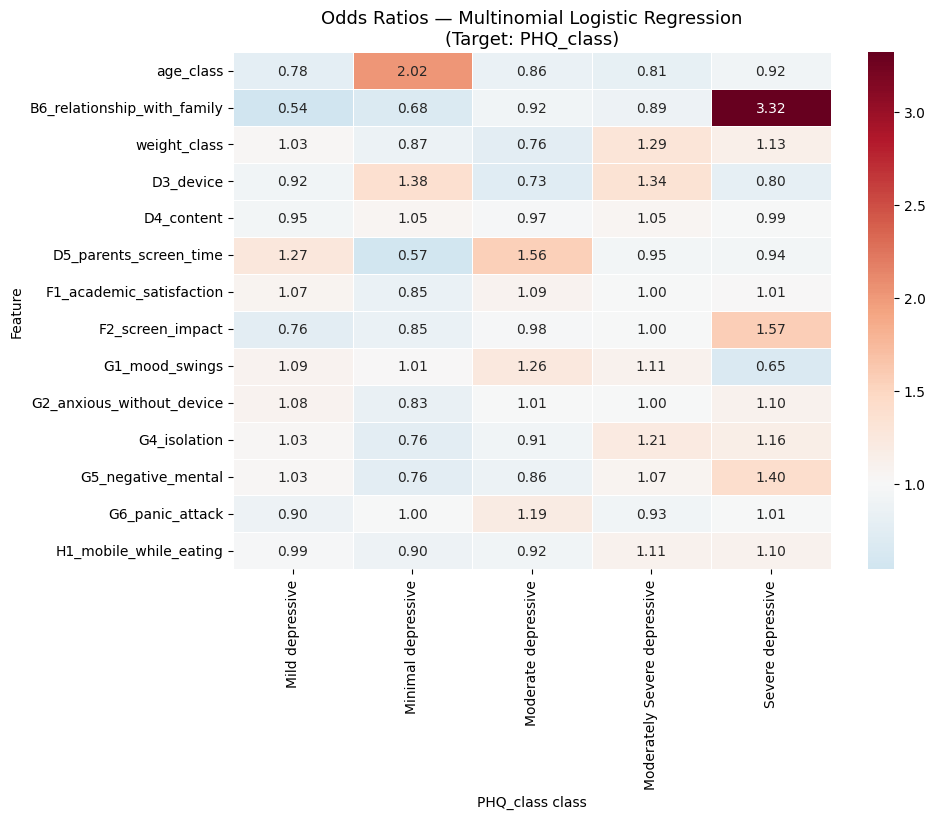

In [15]:
# Odds Ratio Heatmap
import seaborn as sns

fig, ax = plt.subplots(figsize=(max(8, len(class_names) * 2), len(features) * 0.45 + 2))
sns.heatmap(
    odds_ratio_df,
    annot=True, fmt=".2f",
    center=1.0,
    cmap="RdBu_r",
    linewidths=0.4,
    ax=ax
)
ax.set_title("Odds Ratios — Multinomial Logistic Regression\n(Target: PHQ_class)", fontsize=13)
ax.set_xlabel("PHQ_class class")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

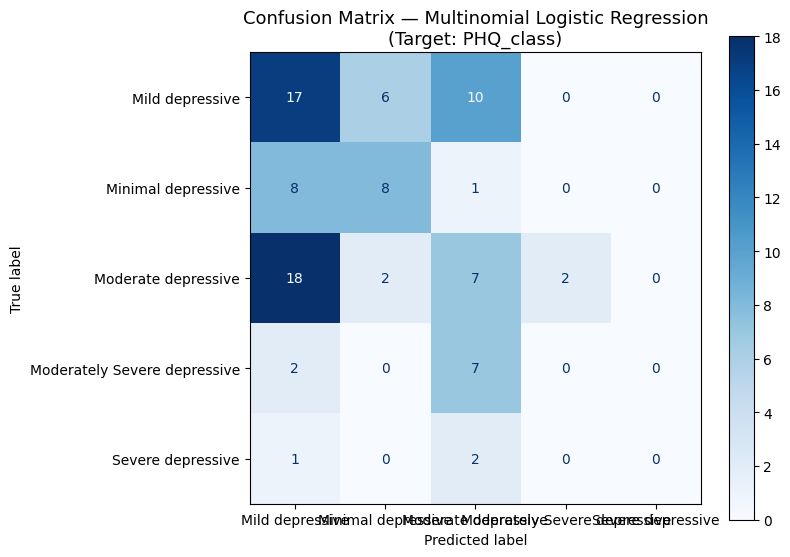

In [16]:
# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title("Confusion Matrix — Multinomial Logistic Regression\n(Target: PHQ_class)", fontsize=13)
plt.tight_layout()
plt.show()

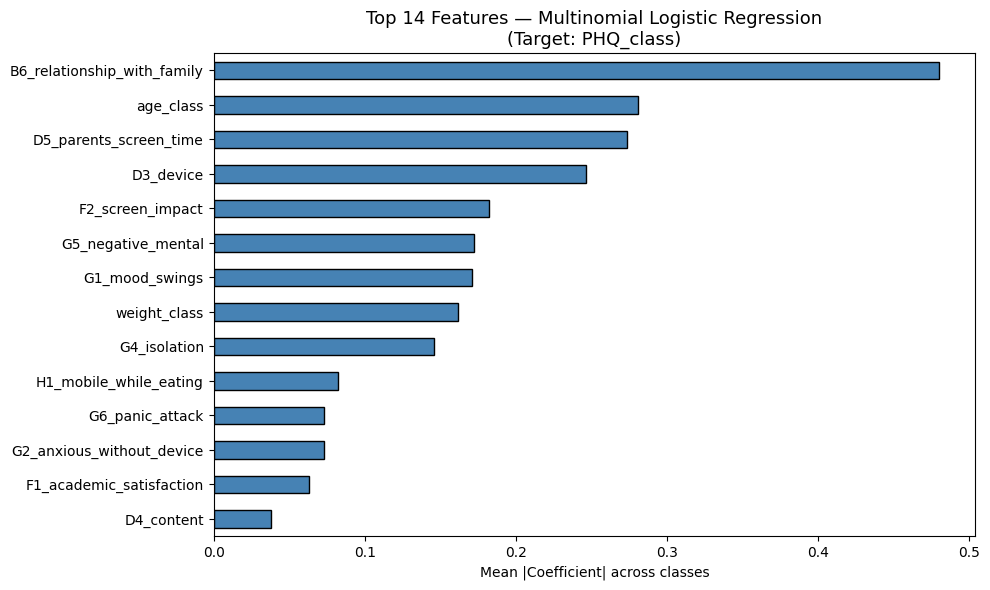


Top 14 features by mean absolute coefficient:
                             mean_abs
B6_relationship_with_family  0.480059
age_class                    0.280991
D5_parents_screen_time       0.273271
D3_device                    0.246732
F2_screen_impact             0.182483
G5_negative_mental           0.172100
G1_mood_swings               0.171062
weight_class                 0.161679
G4_isolation                 0.146119
H1_mobile_while_eating       0.082007
G6_panic_attack              0.073388
G2_anxious_without_device    0.073212
F1_academic_satisfaction     0.062880
D4_content                   0.038206


In [17]:
# 6. Feature Importance (Coefficients)
coef_df = pd.DataFrame(
    mlr.coef_,
    index=class_names,
    columns=features
).T

# Mean absolute coefficient across classes → overall importance
coef_df['mean_abs'] = coef_df.abs().mean(axis=1)
coef_df_sorted = coef_df.sort_values('mean_abs', ascending=False)

top_n = min(20, len(features))
fig, ax = plt.subplots(figsize=(10, 6))
coef_df_sorted['mean_abs'].head(top_n).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='black'
)
ax.set_xlabel("Mean |Coefficient| across classes")
ax.set_title(f"Top {top_n} Features — Multinomial Logistic Regression\n(Target: PHQ_class)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nTop {top_n} features by mean absolute coefficient:")
print(coef_df_sorted[['mean_abs']].head(top_n).to_string())